# Tutorial 1 - WaveBot
The goal of this tutorial is to familiarize new users with how to set up and run optimization problems using WecOptTool. 
This tutorial uses a one-body WEC, the WaveBot, in one degree of freedom in regular waves. 

![WaveBot Photo](https://live.staticflickr.com/65535/51855905347_de87ccaaba_z.jpg)

At the end of this tutorial the user will perform control co-design of the WEC geometry and a corresponding optimal controller to maximize electrical power. 
We build up to this problem in three parts of successive complexity:

1. [Optimal control for maximum mechanical power](#1.-Optimal-control-for-maximum-mechanical-power)
2. [Optimal control for maximum electrical power](#2.-Optimal-control-for-maximum-electrical-power)
3. [Control co-design of the WEC's geometry for maximum electrical power](#3.-Control-co-design-of-the-WEC-geometry-for-maximum-electrical-power)

We will start by loading the necessary modules: 

* Import Autograd (wrapper on NumPy, required) for [automatic differentiation](https://sandialabs.github.io/WecOptTool/theory.html#automatic-differentiation)
* Import other packages we will use in this tutorial
* Import WecOptTool 

In [1]:
import numpy as np
import jax.numpy as jnp
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
import matplotlib.pyplot as plt
from scipy.optimize import brute
import openmdao.api as om
import dymos as dm
import os

import wecopttool as wot

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

## 1. Optimal control for maximum mechanical power
This example illustrates how to set up, run, and analyze a basic optimization problem using WecOptTool.

The objective of this example is to **find the optimal PTO force time series** that produces the most mechanical power subject to the WEC dynamics and a maximum force the PTO can exert.

WecOptTool requires the following to be defined to successfully run its optimization routines:

* The wave environment
* The WEC object, including all of its properties and constraints
* The objective function

The graphic below shows all the requirements for this first part of the tutorial: the wave environment on the left, the WEC object(with its relevant subcomponents) in the blue box in the middle, and the objective function (mechanical power) on the right.

<div>
<img src="https://live.staticflickr.com/65535/52435098523_37d6a2ca94_k.jpg" width="1000">
</div>

### Waves and WEC geometry
The pseudo-spectral solution used in WecOptTool requires a specified set of frequencies to analyze.
To model the WEC accurately, we need to ensure the set of selected frequencies captures the full hydrodynamic response range of the WEC.

Therefore, we start our WecOptTool model by defining this set of frequencies, the wave environment, and the mesh of the WEC geometry.
This ensures the minimum wavelength in the selected frequencies is larger than the minimum wavelength that can be analyzed with the mesh using the Boundary Element Method (BEM), which we will do [later](#bem-solution).
This is a good initial check to make sure the hydrodynamic properties results calculated with the BEM will be accurate.

#### Frequency selection
To start with a simple case in this tutorial, we are interested in modeling a regular wave at 0.3 Hz.
In regular waves, the linear WEC system response will always occur at the wave frequency, with the nonlinear system response also occurring at the corresponding odd harmonics (3rd, 5th, etc.) of the wave frequency.
Thus, we can set the fundamental frequency in our set, $f_1$, equal to the wave frequency.
Prior WaveBot analysis has found that the nonlinear dynamics are sufficiently captured with the 3rd, 5th, 7th, and 9th harmonics.
WecOptTool assumes the spacing between frequencies equals the magnitude of $f_1$. Therefore, we will model 10 frequencies to encompass these harmonics.

These frequencies will be used for the Fourier representation of both the wave and the desired PTO force in the pseudo-spectral problem.
See the [Theory](https://sandialabs.github.io/WecOptTool/theory.html) section of the WecOptTool documentation for more details on the pseudo-spectral problem formulation.

It is important to use the lowest number of frequencies possible while still maintaining accuracy in order to minimize degrees of freedom and computation time for the optimization solver.

In [2]:
wavefreq = 0.3 # Hz
f1 = wavefreq
nfreq = 6

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency

#### Waves
WecOptTool is configured to have the wave environment specified as a 2-dimensional `xarray.DataArray` containing the complex wave amplitudes (in meters), wave phases (in degrees), and directions (in degrees).
We will use an amplitude of 0.0625 meters, a phase of 30 degrees, and direction 0 for this tutorial.
The two coordinates are the radial frequency ``omega`` (in rad/s)  and the direction ``wave_direction`` (in radians).

The `xarray` package has a pretty steep learning curve, so WecOptTool includes the `waves` module containing more intuitive functions that create `xarray.DataArray` objects for different types of wave environments.
See the `xarray` documentation [here](https://docs.xarray.dev/en/latest/index.html) if you are interested in learning more about the package.
In this case, we will use the `wecopttool.waves.regular_wave` function with our wave frequency, amplitude, phase, and direction:

In [3]:
amplitude = 0.0625 # m
phase = 30 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.
The WaveBot mesh is pre-defined in the `wecopttool.geom` module, so we will call it directly from there.
Note that the Capytaine `from_meshio` method can also import from other file types (STL, VTK, MSH, etc.), click [here](https://pypi.org/project/meshio/) for the full list of compatible mesh file types.

We also apply an internal lid which helps eliminate irregular frequency spikes. 
The lid position was chosen by iterating through a series of mesh size factors and lid positions to move the frequency spikes above the range of interest. 
See the `capytaine` documentation [here](https://capytaine.github.io/stable/index.html#) for more details. 

In [4]:
wb = wot.geom.WaveBot()  # use standard dimensions
mesh_size_factor = 0.2 # 1.0 for default, smaller to refine mesh
mesh = wb.mesh(mesh_size_factor)

# create mesh object for WaveBot and add internal lid
mesh_obj = load_from_meshio(mesh, 'WaveBot')
lid_mesh = mesh_obj.generate_lid(-2e-2)

fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="WaveBot")

We can also visualize the mesh for inspection.
Capytaine has built-in methods for visualizing meshes (`fb.show`, and `fb.show_matplotlib`). 
These methods are interactive when used outside a Jupyter notebook.  
The included WaveBot example also has a method for plotting the cross-section of the device, `plot_cross_section`. 

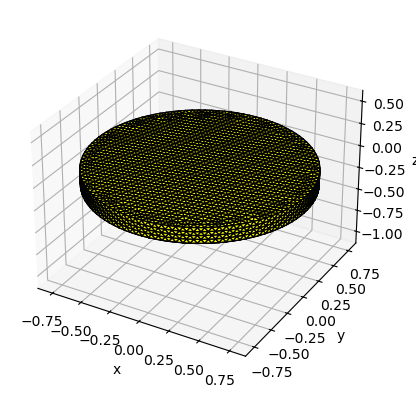

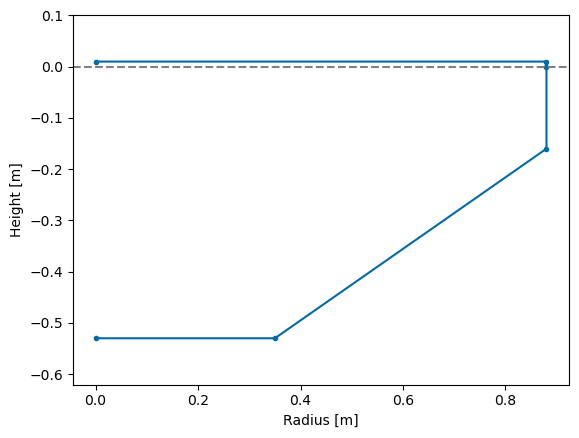

In [5]:
fb.show_matplotlib()
_ = wb.plot_cross_section(show=True) # specific to WaveBot

#### Minimum wavelength check
With the frequency vector, wave environment, and geometry mesh all defined, we can now check to make sure they are all suitable to accurately simulate the WEC dynamics.
The `fb.minimal_computable_wavelength` method checks the mesh to determine the minimum wavelength that can be reliably computed using Capytaine.
We compare this value to the minimum wavelength our frequency vector will compute; we want this number to be <u>larger</u> than Capytaine's minimum wavelength.
A warning is printed if this is not the case.
This warning is ignored here because the BEM results have been validated, but can be used as a guide for mesh refinement to ensure accurate BEM results.

In [6]:
min_computable_wavelength = fb.minimal_computable_wavelength
g = 9.81
min_period = 1/(f1*nfreq)
min_wavelength = (g*(min_period)**2)/(2*np.pi)

if min_wavelength < min_computable_wavelength:
    print(f'Warning: Minimum wavelength in frequency spectrum ({min_wavelength}) is smaller'
         f' than the minimum computable wavelength ({min_computable_wavelength}).')

### WEC object
The `WEC` object in WecOptTool contains all the information about the WEC and its properties and dynamics.
This constitutes the vast majority of the setup required to run a WecOptTool optimization.
The WEC object handles three categories of data that are passed on to the optimizer:

1. The intrinsic impedance of the WEC
2. The WEC and PTO kinematic
3. The PTO dynamics

In order for the `WEC` object to be able to compute these data, we must provide information when we declare the object in the code.
The required information includes:

* [Degrees of freedom to consider](#degrees-of-freedom)
* [Linear hydrodynamic coefficients](#bem-solution)
* Any additional loads (e.g. PTO force, mooring, non-linear hydrodynamics)
* Device constraints

Again, we will keep things simple to start.
We will only consider heave motion and assume a lossless PTO, and the WaveBot has trivial WEC-PTO kinematics (unity).
We will apply one additional force (the PTO force on the WEC) and one constraint (the maximum PTO force), which [we define below using the PTO class](#pto).

#### Degrees of freedom
The degrees of freedom can be added directly to the `FloatingBody` using the `add_translation_dof` and `add_rotation_dof` methods. The axis of rotation is automatically defined if the method is supplied a name of `"Surge"`, `"Sway"`, `"Heave"`, `"Roll"`, `"Pitch"`, or `"Yaw"`. We will only model the heave degree of freedom in this case.

In [7]:
fb.add_translation_dof(name="Heave")
ndof = fb.nb_dofs

#### BEM solution

We can use the `FloatingBody` and frequency vector created earlier to run the Boundary Element Method solver in Capytaine to get the hydrostatic and hydrodynamic coefficients of our WEC object.
This is wrapped into the `wecopttool.run_bem` function.

If you would like to save the BEM data to a NetCDF file for future use, uncomment the second line of the cell below to use the `wot.write_netcdf` function.

In [8]:
bem_data_file = f'bem_wb_{nfreq}.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(fb, freq, wave_dirs=0)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data)

In [9]:
#solve using wecopttool first

wec = wot.WEC.from_bem(
    bem_data,
    constraints=[],
    friction=None,
    f_add={},
)

obj_fun = lambda wec_, x_wec, x_opt, waves_: 0
nstate_opt = 0

options = {'maxiter': 200}
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    optim_options=options,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
    )

opt_mechanical_average_power = results[0].fun
print(f'Optimal average mechanical power: {opt_mechanical_average_power} W')

nsubsteps = 5
#pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1
Optimal average mechanical power: 0.0 W


In [10]:
# setup dymos case
import openmdao.api as om

prob, traj, phase = wot.setup_dymos_problem(bem_data, wavefreq, nfreq, f1, waves,
                                            driver=om.pyOptSparseDriver(), optimizer = 'IPOPT',
                                            transcription=dm.GaussLobatto(num_segments=10, order=3),
                                            scale_x_wec=1, scale_control=1e-2, scale_energy=1e-3,
                                            opt=False)


In [11]:
prob.run_driver()
sim_out = traj.simulate(times_per_seg=50)

c:\Users\jtgrasb\AppData\Local\anaconda3\envs\dymos_wot\lib\site-packages\openmdao\core\driver.py:1276: DriverWarning:pyOptSparseDriver: objective(s) ['traj.phase0.t'] do not depend on any design variables. Please check your problem formulation.



Jacobian shape: (33, 32)  (47.44% nonzero)
FWD solves: 22   REV solves: 0
Total colors vs. total size: 22 vs 32  (31.25% improvement)

Sparsity computed using tolerance: 1e-25.
Dense total jacobian for Problem 'problem' was computed 3 times.
Time to compute sparsity:   6.6861 sec
Time to compute coloring:   0.0655 sec
Memory to compute coloring:   0.0742 MB
Coloring created on: 2026-03-20 16:53:36


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\dymos_wot\lib\site-packages\openmdao\core\total_jac.py:1670: DerivativesWarning:The following constraints or objectives cannot be impacted by the design variables of the problem at the current design point:
  traj.phase0.t, inds=[29]





Optimization Problem -- Optimization using pyOpt_sparse
    Objective Function: _objfunc

    Solution: 
--------------------------------------------------------------------------------
    Total Time:                    5.4099
       User Objective Time :       0.9959
       User Sensitivity Time :     4.3171
       Interface Time :            0.0272
       Opt Solver Time:            0.0697
    Calls to Objective Function :      16
    Calls to Sens Function :           16


   Objectives
      Index  Name                     Value
          0  traj.phase0.t     3.333333E+00

   Variables (c - continuous, i - integer, d - discrete)
      Index  Name                          Type      Lower Bound            Value      Upper Bound     Status
          0  traj.phase0.states:x_0           c    -1.000000E+21     5.489243E-02     1.000000E+21           
          1  traj.phase0.states:x_1           c    -1.000000E+21     2.538117E-02     1.000000E+21           
          2  traj.phase0.s

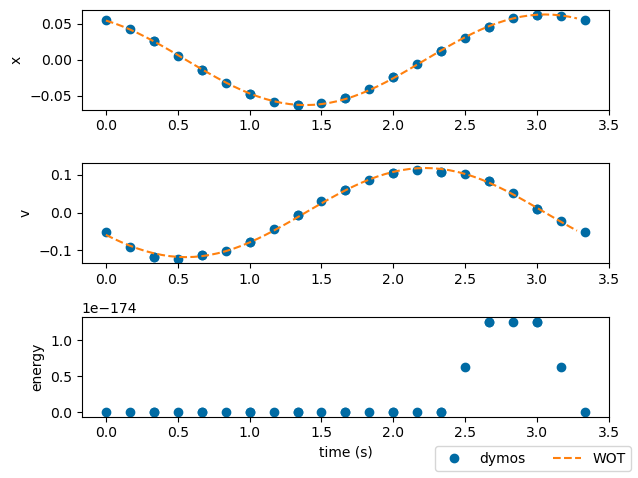

In [12]:

# Plot the state values obtained from the phase timeseries objects in the simulation output.
t_sol = prob.get_val('traj.phase0.timeseries.time')

states = ['x', 'v','energy']
wot_states = ['pos','vel','energy']
fig, axes = plt.subplots(len(states), 1)
for i, (wot_state, state) in enumerate(zip(wot_states,states)):
    sol = axes[i].plot(t_sol, prob.get_val(f'traj.phase0.timeseries.{state}'), 'o')
    if wot_state != 'energy':
        wot_plots = axes[i].plot(wec_tdom['time'], np.squeeze(wec_tdom[wot_state]), '--')
    axes[i].set_ylabel(state)
axes[-1].set_xlabel('time (s)')
fig.legend((sol[0], wot_plots[0]), ('dymos', 'WOT'), loc='lower right', ncol=2)
plt.tight_layout()
plt.show()
